In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)

plt.style.use('seaborn-v0_8')

print("Libraries loaded")

Libraries loaded


In [4]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape, y.shape)

(284807, 30) (284807,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"Test fraud rate: {y_test.mean():.4f}")

Train: (227845, 30), Test: (56962, 30)
Train fraud rate: 0.0017
Test fraud rate: 0.0017


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(f"Mean of Amount column before scaling: {X_train['Amount'].mean():.2f}")
print(f"Mean of Amount column after scaling: {X_train_scaled[:, -2].mean():.4f}")

Scaling complete
Mean of Amount column before scaling: 88.18
Mean of Amount column after scaling: -0.0000


In [7]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print("Naive Baseline (predict everything as normal)")
print(f"Accuracy: {(y_pred_dummy == y_test).mean():.4f}")
print(classification_report(y_test, y_pred_dummy, 
      target_names=['Normal', 'Fraud'], zero_division=0))

Naive Baseline (predict everything as normal)
Accuracy: 0.9983
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Normal', 'Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.4f}")

Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9605


In [9]:
# SMOTE oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE - Normal: {sum(y_train == 0)}, Fraud: {sum(y_train == 1)}")
print(f"After SMOTE  - Normal: {sum(y_train_smote == 0)}, Fraud: {sum(y_train_smote == 1)}")

Before SMOTE - Normal: 227451, Fraud: 394
After SMOTE  - Normal: 227451, Fraud: 227451


In [10]:
# Logistic Regression with SMOTE
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)

print("Logistic Regression with SMOTE")
print(classification_report(y_test, y_pred_lr_smote, 
      target_names=['Normal', 'Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_smote.predict_proba(X_test_scaled)[:, 1]):.4f}")

Logistic Regression with SMOTE
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9708


In [12]:
# Logistic Regression with class weights
lr_weighted = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_weighted.fit(X_train_scaled, y_train)
y_pred_lr_weighted = lr_weighted.predict(X_test_scaled)

print("Logistic Regression with Class Weights")
print(classification_report(y_test, y_pred_lr_weighted, 
      target_names=['Normal', 'Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_weighted.predict_proba(X_test_scaled)[:, 1]):.4f}")

Logistic Regression with Class Weights
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721


In [13]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest")
print(classification_report(y_test, y_pred_rf, 
      target_names=['Normal', 'Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1]):.4f}")

Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9529


In [16]:
# XGBoost
from xgboost import XGBClassifier

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb, 
      target_names=['Normal', 'Fraud'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:, 1]):.4f}")

XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9682


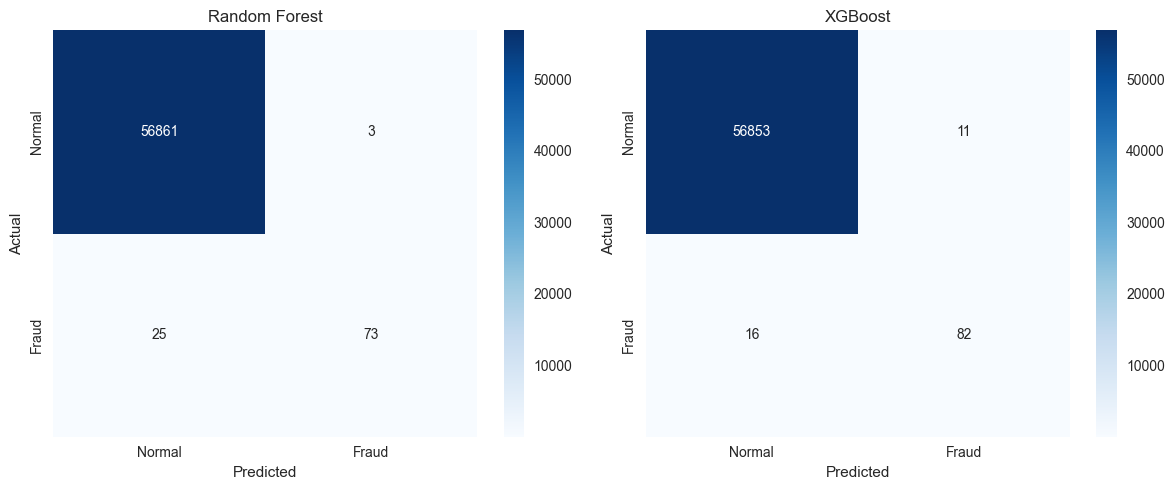

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150)
plt.show()